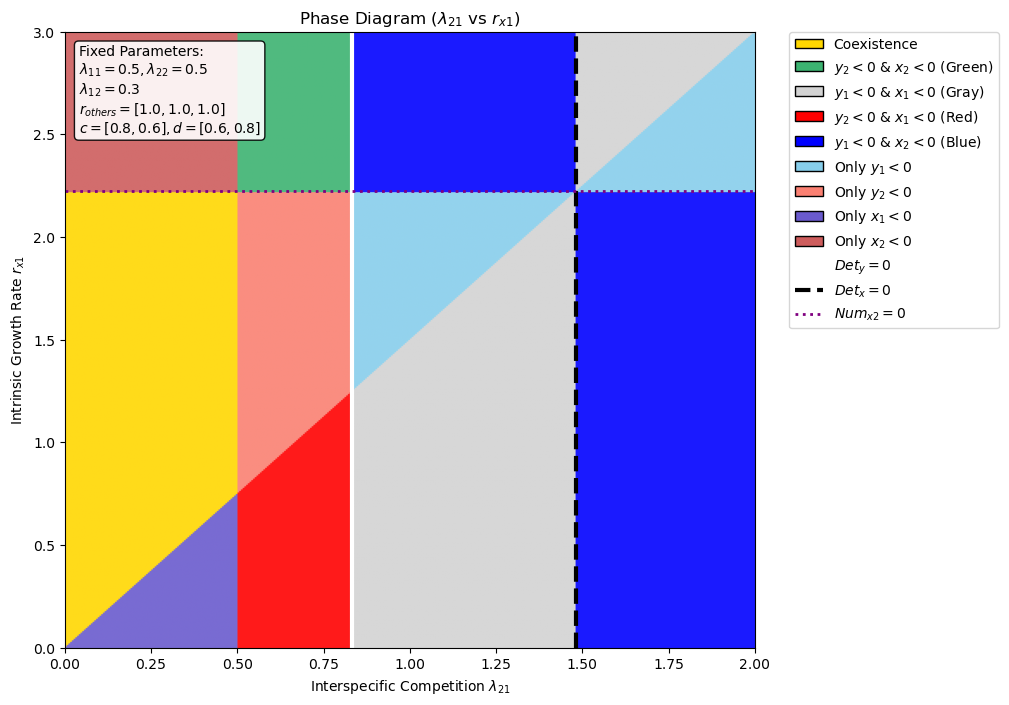

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 1. パラメータ設定
params_fixed = {
    'r_others': [1.0, 1.0, 1.0],    # [ry1, rx2, ry2]
    'lambda_diag': [0.5, 0.5],      # [lambda11, lambda22] <- l11(0.5)を固定値に追加
    'lambda_12': 0.3,               # l21が変数になるため、l12のみ固定
    'c': [0.8, 0.6],                # [c1, c2]
    'd': [0.6, 0.8]                 # [d1, d2]
}

ry1, rx2, ry2 = params_fixed['r_others']
l11, l22 = params_fixed['lambda_diag']
l12 = params_fixed['lambda_12']
c1, c2 = params_fixed['c']
d1, d2 = params_fixed['d']

# 2. メッシュグリッド
res = 400
l21_vals = np.linspace(0.001, 2.0, res) # X軸: l21 に変更
rx1_vals = np.linspace(0.001, 3.0, res) # Y軸: rx1
L21, RX1 = np.meshgrid(l21_vals, rx1_vals)
# 3. 計算
Det_x = c1 * d2 * l11 * l22 - c2 * d1 * l12 * L21
Det_y = l11 * l22 - l12 * L21

Num_x1 = d2 * l22 * RX1 - d1 * L21 * rx2
Num_x2 = c1 * l11 * rx2 - c2 * l12 * RX1
Num_y1 = l22 * ry1 - l12 * ry2
Num_y2 = l11 * ry2 - L21 * ry1

with np.errstate(divide='ignore', invalid='ignore'):
    X1 = Num_x1 / Det_x
    X2 = Num_x2 / Det_x
    Y1 = Num_y1 / Det_y
    Y2 = Num_y2 / Det_y
# 4. 領域のカテゴリ分け
Category = np.zeros_like(X1, dtype=int)

pos_x1 = X1 > 0
pos_x2 = X2 > 0
pos_y1 = Y1 > 0
pos_y2 = Y2 > 0

# --- Step 1: 単独条件（背景） ---
Category[~pos_y1] = 2
Category[~pos_y2] = 3
Category[~pos_x1] = 4
Category[~pos_x2] = 5

# --- Step 2: 複合条件（優先度高） ---
mask_green = (~pos_y2) & (~pos_x2)
mask_gray  = (~pos_y1) & (~pos_x1)
mask_red   = (~pos_y2) & (~pos_x1)
mask_blue  = (~pos_y1) & (~pos_x2)

Category[mask_green] = 6
Category[mask_gray]  = 7
Category[mask_red]   = 8
Category[mask_blue]  = 9

# --- Step 3: 共存（最優先） ---
mask_coexist = pos_x1 & pos_x2 & pos_y1 & pos_y2
Category[mask_coexist] = 1

# 5. プロット
# （前略：計算ロジックまではそのまま）

# --- 5. プロット ---
# 凡例スペースを確保するため、少し横長にします
fig, ax = plt.subplots(figsize=(12, 8))

# カラーマップ設定
colors = [
    'white',        # 0
    'gold',         # 1: Coexist
    'skyblue',      # 2: y1<0
    'salmon',       # 3: y2<0
    'SlateBlue',    # 4: x1<0
    'IndianRed',    # 5: x2<0
    'MediumSeaGreen', # 6: Green
    'lightgray',    # 7: Gray
    'red',          # 8: Red
    'blue'          # 9: Blue
]
cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, 10.5, 1), cmap.N)

# 描画
im = ax.imshow(Category, extent=[0, 2.0, 0, 3.0], origin='lower',
               cmap=cmap, norm=norm, aspect='auto', alpha=0.9)



# --- 補助線 ---
# Det_y = 0 line (L21について解く)
singularity_y_val = (l11 * l22) / l12

# Det_x = 0 line (L21について解く)
num_sing_x = c1 * d2 * l11 * l22
den_sing_x = c2 * d1 * l12
singularity_x_val = num_sing_x / den_sing_x

# Num_x2 = 0 line (RX1について解くと定数になるため、水平線になる)
rx1_hline_val = (c1 * l11 * rx2) / (c2 * l12)

# 今回はX軸がL21なので axvline で描画します
ax.axvline(x=singularity_y_val, color='white', linestyle='-', linewidth=3, label=r'Singularity ($Det_y = 0$)')
ax.axvline(x=singularity_x_val, color='black', linestyle='--', linewidth=3, label=r'Singularity ($Det_x = 0$)')
ax.axhline(y=rx1_hline_val, color='purple', linestyle=':', linewidth=2, label=r'$Num_{x2}=0$ Boundary')

# --- ラベル設定 ---
ax.set_xlabel(r'Interspecific Competition $\lambda_{21}$') # ラベルを変更
ax.set_ylabel(r'Intrinsic Growth Rate $r_{x1}$')
ax.set_title(r'Phase Diagram ($\lambda_{21}$ vs $r_{x1}$)')   # タイトルを変更
ax.set_xlim(0, 2.0)
ax.set_ylim(0, 3.0)

# テキスト表示も変更
textstr = '\n'.join((
    r'Fixed Parameters:',
    r'$\lambda_{11} = %.1f, \lambda_{22} = %.1f$' % (l11, l22),
    r'$\lambda_{12} = %.1f$' % l12,
    r'$r_{others} = [%.1f, %.1f, %.1f]$' % (ry1, rx2, ry2),
    r'$c=[%.1f, %.1f], d=[%.1f, %.1f]$' % (c1, c2, d1, d2)
))
props = dict(boxstyle='round', facecolor='white', alpha=0.9)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=props)
# --- 凡例設定 (修正ポイント) ---
legend_elements = [
    Patch(facecolor='gold', edgecolor='k', label='Coexistence'),
    Patch(facecolor='MediumSeaGreen', edgecolor='k', label='$y_2 < 0$ & $x_2 < 0$ (Green)'),
    Patch(facecolor='lightgray', edgecolor='k', label='$y_1 < 0$ & $x_1 < 0$ (Gray)'),
    Patch(facecolor='red', edgecolor='k', label='$y_2 < 0$ & $x_1 < 0$ (Red)'),
    Patch(facecolor='blue', edgecolor='k', label='$y_1 < 0$ & $x_2 < 0$ (Blue)'),
    # 単独絶滅も念のため表示
    Patch(facecolor='skyblue', edgecolor='k', label='Only $y_1 < 0$'),
    Patch(facecolor='salmon', edgecolor='k', label='Only $y_2 < 0$'),
    Patch(facecolor='SlateBlue', edgecolor='k', label='Only $x_1 < 0$'),
    Patch(facecolor='IndianRed', edgecolor='k', label='Only $x_2 < 0$'),
    
    Line2D([0], [0], color='white', lw=3, label=r'$Det_y=0$'),
    Line2D([0], [0], color='black', linestyle='--', lw=3, label=r'$Det_x=0$'),
    Line2D([0], [0], color='purple', linestyle=':', lw=2, label=r'$Num_{x2}=0$')
]

# グラフの右側(right=0.7)までしか図を描画せず、残り(0.3)を凡例用に空ける
plt.subplots_adjust(right=0.7)

# 凡例を枠外(1.05)に配置
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.05, 1.0), borderaxespad=0.)
#plt.savefig("l12_rx1.png",dpi=300)
plt.show()